In [131]:
import pandas as pd
import glob

# Update the file pattern to include the directory "data/"
file_pattern = "data/drug_resistant_*.tsv"
files = glob.glob(file_pattern)

# Initialize an empty DataFrame to store the union of all data
union_data = pd.DataFrame()

# Loop through each file and append its data to the union DataFrame
for file in files:
    df = pd.read_csv(file, sep="\t")  # Read the TSV file
    union_data = pd.concat([union_data, df], ignore_index=True)

# Drop duplicate rows to ensure a union of all data
union_data = union_data.drop_duplicates()

# Display the resulting union DataFrame
print(union_data)

     Position Consensus DRM
0         100         L   I
1         101         K   P
2         103         K   N
3         103         K   T
4         103         K   S
..        ...       ...  ..
150       215         T   N
151       215         T   S
153       219         K   N
154       219         K   Q
155       219         K   R

[109 rows x 3 columns]


translate union data with the data/RT.reduce4.redux, where file look like this:
39 -HQCWGRDSNFMLIPV AEY K T
40 -CWMSLYF AGNTPVHRIQK D E
41 -KHYRNT APWCFDVGQSI EL M
42 -HIAMNPQSWYFVLTR CKD E G
43 -WFGIYPSMR ACVHDTE K LNQ
44 -ACPW DHMRLYNTQSV E FKIG
45 -LHWADIMNPQSTVY CG E FKR
46 -KFCHSVWY ANMTLPR DQ EGI
47 -WAKRGQTDMHPSYCVF EN I L
48 -WYRKINFCLGQADVMP E HT S
49 -VIFWYALNDR CE GMQHPST K
50 -LRWYKCFDS ANHPTM EI GQV

here, for example, at first row, means at pos 39, if the consensus/ DRM is HQCWGRDSNFMLIPV, its reduce to A, AEY to B, K to C, T to D

now get a union data reduced with reduced alphabet with above rule in the redux file

In [132]:
# Step 1: Parse the redux file to create a mapping of positions and reduction rules
redux_file = "data/RT.reduce4.redux"
reduction_rules = {}
cut_off_low = 39
cut_off_high = 226
with open(redux_file, "r") as file:
    for line in file:
        parts = line.strip().split()
        position = int(parts[0])
        rules = parts[1:]
        reduction_rules[position] = {char: chr(65 + i) for i, group in enumerate(rules) for char in group}

# Step 2: Define a function to apply the reduction rules
def reduce_alphabet(row):
    position = row["Position"]
    consensus = row["Consensus"]
    drm = row["DRM"]
    if position in reduction_rules:
        rules = reduction_rules[position]
        reduced_consensus = rules.get(consensus, consensus)
        reduced_drm = rules.get(drm, drm)
        return pd.Series([reduced_consensus, reduced_drm])
    return pd.Series([consensus, drm])

# Step 3: Apply the reduction rules to the union_data DataFrame
union_data = union_data[(union_data["Position"] >= cut_off_low) & (union_data["Position"] <= cut_off_high)]
union_data[["Reduced_Consensus", "Reduced_DRM"]] = union_data.apply(reduce_alphabet, axis=1)

# Display the updated DataFrame
print(union_data)

     Position Consensus DRM Reduced_Consensus Reduced_DRM
0         100         L   I                 C           B
1         101         K   P                 C           D
2         103         K   N                 C           B
3         103         K   T                 C           B
4         103         K   S                 C           D
..        ...       ...  ..               ...         ...
150       215         T   N                 D           A
151       215         T   S                 D           A
153       219         K   N                 C           B
154       219         K   Q                 C           D
155       219         K   R                 C           B

[96 rows x 5 columns]


Now go through the file data/RT.reduce4.seq, for each sequence, its starts at 'start_aa' in this case for rt is 39. 
calculate the mutation rate for each DRM (number of that drm happen in all seuqences) with the reduced Consensus and reduced DRM in the union data and put it in the end of union data

In [133]:
# Step 1: Read the sequences from the file
sequences = []
start_aa = 39  # Starting amino acid position for RT
with open("data/RT.reduce4.seq", "r") as seq_file:
    for line in seq_file:
        if line.strip():  # Skip empty lines
            sequences.append(line.strip())

# Step 2: Define a function to calculate the mutation rate for each DRM
def calculate_mutation_rate(row):
    position = row["Position"]
    reduced_drm = row["Reduced_DRM"]
    actual_index = position - start_aa
    # print(actual_index)
    count = sum(1 for seq in sequences if seq[actual_index] == reduced_drm)
    return count / len(sequences)

# Step 3: Apply the mutation rate calculation to the union_data DataFrame
union_data["Mutation_Rate"] = union_data.apply(calculate_mutation_rate, axis=1)

# Display the updated DataFrame
# Sort the DataFrame by Mutation_Rate in descending order and print it
print(union_data.sort_values(by="Mutation_Rate", ascending=False))

     Position Consensus DRM Reduced_Consensus Reduced_DRM  Mutation_Rate
72        179         V   E                 B           B       0.848442
117        69         T   G                 B           B       0.840002
40        184         M   V                 B           C       0.547984
25         41         M   L                 D           C       0.400177
2         103         K   N                 C           B       0.376107
..        ...       ...  ..               ...         ...            ...
82        188         Y   C                 D           C       0.002449
108        65         K   E                 B           A       0.001355
52        100         L   V                 C           D       0.001198
136       151         Q   L                 D           B       0.000886
109        65         K   N                 B           D       0.000677

[96 rows x 6 columns]


filter out the less than one percent mutation rate rows

In [134]:
# Filter rows where Mutation_Rate is greater than or equal to 0.01 (1%)
filtered_drm= union_data[union_data["Mutation_Rate"] >= 0.01]

# Display the filtered DataFrame
print(filtered_drm)

     Position Consensus DRM Reduced_Consensus Reduced_DRM  Mutation_Rate
0         100         L   I                 C           B       0.054600
1         101         K   P                 C           D       0.015005
2         103         K   N                 C           B       0.376107
3         103         K   T                 C           B       0.376107
4         103         K   S                 C           D       0.023184
..        ...       ...  ..               ...         ...            ...
150       215         T   N                 D           A       0.033552
151       215         T   S                 D           A       0.033552
153       219         K   N                 C           B       0.086381
154       219         K   Q                 C           D       0.126289
155       219         K   R                 C           B       0.086381

[76 rows x 6 columns]


in dde sorted, if the mutation consensus and drm match the filtered_drm consensus and drm

[('B', 116, 'C', 'D', 151, 'C', 4.382362), ('D', 41, 'C', 'D', 215, 'C', 3.4362667), ('A', 75, 'D', 'C', 77, 'D', 3.3571672), ('C', 101, 'A', 'D', 190, 'C', 3.3036745), ('D', 203, 'B', 'C', 223, 'B', 3.1906276), ('C', 173, 'A', 'B', 174, 'D', 3.1660094), ('D', 169, 'B', 'C', 173, 'B', 3.0441403), ('C', 43, 'B', 'C', 44, 'A', 2.9103718), ('A', 75, 'C', 'C', 132, 'D', 2.900959), ('C', 70, 'D', 'C', 219, 'A', 2.772025)]
{('A', 210, 'D'), ('B', 98, 'C'), ('C', 70, 'D'), ('C', 103, 'D'), ('D', 90, 'C'), ('D', 106, 'B'), ('B', 184, 'C'), ('B', 65, 'C'), ('A', 75, 'B'), ('C', 100, 'B'), ('C', 219, 'B'), ('B', 69, 'C'), ('D', 215, 'C'), ('C', 70, 'B'), ('A', 75, 'D'), ('C', 219, 'D'), ('D', 41, 'C'), ('D', 74, 'C'), ('C', 221, 'D'), ('A', 67, 'C'), ('B', 179, 'C'), ('D', 215, 'A'), ('D', 151, 'C'), ('C', 101, 'A'), ('B', 179, 'A'), ('D', 190, 'C'), ('C', 138, 'B'), ('B', 69, 'B'), ('C', 219, 'A'), ('D', 215, 'B'), ('D', 74, 'B'), ('B', 184, 'D'), ('C', 103, 'A'), ('B', 108, 'C'), ('D', 181, 'A

Filtering pairs: 100%|██████████| 158202/158202 [00:00<00:00, 1933987.61it/s]
C:\Users\xuech\AppData\Local\Temp\ipykernel_29460\2853089085.py:119: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('bwr_r')


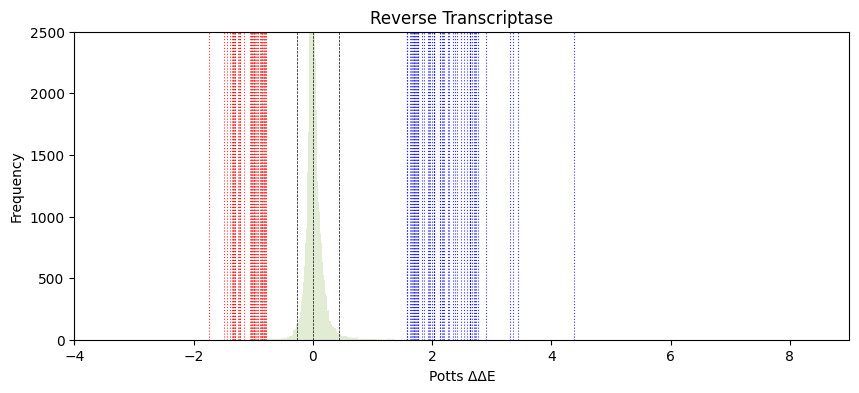

In [135]:
# Initialize dictionaries to store delta E and delta delta E values
import collections
import re

delta_e_per_position = collections.defaultdict(lambda: [0.0, 0.0, 0.0, 0.0])
delta_delta_e_per_pair = []

# Define mutation_map to map amino acids to indices
mutation_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3}

# Read the file and process the data
with open('data/kn.her2.all') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        columns = re.split(r'[,\t\s]+', line)
        mutations = columns[0]
        ddE = float(columns[1])
        delta_e1 = float(columns[3])
        delta_e2 = float(columns[4])
        
        # Extract positions from the mutation string
        positions = [int(pos) for pos in re.findall(r'\d+', mutations)]
        if len(positions) != 2:
            continue
        
        pos1, pos2 = positions
        
        #detect the wildtype 'first' aa seuqnce, and put A' delta e into [0]....D's delta e into [3]
        # Store delta E values for each position
        # Detect the wildtype 'first' amino acid sequence
        wildtype_aa1 = mutations[0]  # Extract the first amino acid from the mutation string
        wildtype_aa2 = mutations.split('-')[1][0]  # Extract the first letter after '-'
        mutate_aa1 = mutations[mutations.index('-') - 1]  # Extract the one letter before '-'
        mutate_aa2 = mutations[-1]
        # print(f"Processing mutation: {mutations}, Positions: {pos1}, {pos2}, Wildtype AAs: {wildtype_aa1}, {wildtype_aa2}, Mutated AA1: {mutate_aa1}, Mutated AA2: {mutate_aa2}")
        # Map the wildtype amino acid to the corresponding index in the delta_e_per_position list
        if mutate_aa1 in mutation_map:
            delta_e_per_position[pos1][mutation_map[mutate_aa1]] = delta_e1
        if mutate_aa2 in mutation_map:
            delta_e_per_position[pos2][mutation_map[mutate_aa2]] = delta_e2
        
        # Store delta delta E values for each pair of positions
        delta_delta_e_per_pair.append((wildtype_aa1, pos1, mutate_aa1, wildtype_aa2, pos2, mutate_aa2, ddE))

        # Print out the content in delta_delta_e_per_pair
# print(delta_delta_e_per_pair[:10])
##################plot###################################
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize
from tqdm import tqdm

anta_max = -1.16
syner_min = 1.76
# Sort delta_delta_e_per_pair by the third element (ddE value) in descending order
delta_delta_e_per_pair_sorted = sorted(delta_delta_e_per_pair, key=lambda x: x[6], reverse=True)
print(delta_delta_e_per_pair_sorted[:10])
# Extract ddE values from delta_delta_e_per_pair
# Define the filtered DRM consensus and DRM pairs
# Filter the delta_delta_e_per_pair_sorted based on the filtered DRM consensus, position, and DRM pairs
# Create a set of tuples for faster lookup
filtered_drm_tuples = set(
    (row['Reduced_Consensus'], row['Position'], row['Reduced_DRM']) 
    for _, row in filtered_drm.iterrows()
)
print(filtered_drm_tuples)

# Filter pairs using set lookup (much faster)
filtered_pairs = [
    pair for pair in tqdm(delta_delta_e_per_pair_sorted, desc="Filtering pairs")
    if (pair[0], pair[1], pair[2]) in filtered_drm_tuples or
       (pair[3], pair[4], pair[5]) in filtered_drm_tuples
]

# Extract ddE values from the filtered pairs
ddE_values_dr = [pair[6] for pair in filtered_pairs]
ddE_values = [pair[6] for pair in delta_delta_e_per_pair_sorted]
# Create a figure with the desired size
plt.figure(figsize=(10,4))

# Plot the histogram
plt.hist(ddE_values, bins=1000, color='#e2ecd4')
plt.xlabel('Potts ΔΔE')
plt.ylabel('Frequency')
plt.xlim(-4, 9)
plt.title('Reverse Transcriptase')
plt.ylim(0, 2500)

# Calculate the 5th and 95th percentiles
percentile_neg = np.percentile(ddE_values, 1)
mean_ddE = np.mean(ddE_values)
percentile_pos = np.percentile(ddE_values, 99)

# Add black dashed lines for the percentiles
plt.axvline(percentile_neg, color='black', linestyle='--', linewidth=0.5, label='5th Percentile')
plt.axvline(percentile_pos, color='black', linestyle='--', linewidth=0.5, label='95th Percentile')

# Add a red dashed line for the mean
plt.axvline(mean_ddE, color='black', linestyle='--', linewidth=0.5, label='Mean')


top_cutoff = 50  # Number of top positive values
bottom_cutoff = 50  # Number of top negative values

# Sort ddE_values_dr in descending order
sorted_ddE_values_dr = sorted(ddE_values_dr, reverse=True)

# Extract the top positive and top negative values based on the cutoff
top_pos_values = sorted_ddE_values_dr[:top_cutoff]
top_neg_values = sorted_ddE_values_dr[-bottom_cutoff:]

# Add red dashed lines for all top negative values with transparency
# Define normalization and colormap
norm = Normalize(vmin=anta_max, vmax=syner_min)
cmap = cm.get_cmap('bwr_r')

# Add red dashed lines for all top negative values with transparency
for value in top_neg_values:
    color = cmap(norm(value))
    plt.axvline(value, color=color, linestyle=':', linewidth=0.8, alpha=0.8)

# Add blue dashed lines for all top positive values with transparency
for value in top_pos_values:
    color = cmap(norm(value))
    plt.axvline(value, color=color, linestyle=':', linewidth=0.8, alpha=0.8)



# Add legend
# plt.legend()

plt.show()


In [136]:
# Print the first 10 filtered pairs
print(filtered_pairs[:10])

[('B', 116, 'C', 'D', 151, 'C', 4.382362), ('D', 41, 'C', 'D', 215, 'C', 3.4362667), ('A', 75, 'D', 'C', 77, 'D', 3.3571672), ('C', 101, 'A', 'D', 190, 'C', 3.3036745), ('A', 75, 'C', 'C', 132, 'D', 2.900959), ('C', 70, 'D', 'C', 219, 'A', 2.772025), ('A', 67, 'D', 'C', 219, 'D', 2.7301908), ('C', 70, 'D', 'C', 219, 'D', 2.719706), ('A', 210, 'D', 'D', 215, 'C', 2.6954288), ('B', 116, 'C', 'D', 151, 'B', 2.675765)]
